Loading data from ../../local_data/nsidc_distance_to_land.nc...


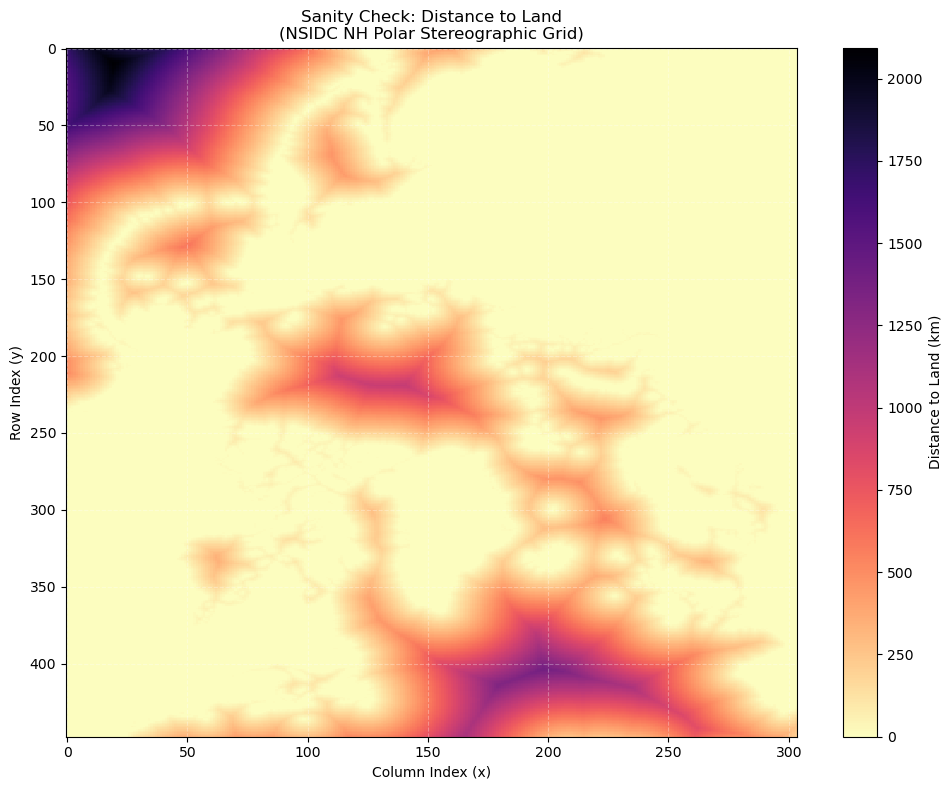

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# path to the generated NetCDF file

file_path = '../../local_data/nsidc_distance_to_land.nc'

try:
    ds = xr.open_dataarray(file_path)
except FileNotFoundError:
    print(f"Error: Could not find {file_path}. Make sure the generation script finished running.")
    exit()

# convert metres to kilometres for easier interpretation on the colorbar

ds_km = ds / 1000.0
ds_km.name = 'Distance to nearest land'
ds_km.attrs['units'] = 'km'

# setup the plot

fig, ax = plt.subplots(figsize=(10, 8))

# xarray wraps matplotlib's pcolormesh/imshow natively
# 'magma_r' or 'viridis' are great colormaps for distance 
# darker = closer, brighter = further

plot = ds_km.plot(
    ax=ax,
    cmap='magma_r', 
    cbar_kwargs={'label': 'Distance to Land (km)'}
)

# The NSIDC grid typically places row 0 at the top (highest Y).
# Inverting the Y-axis makes it match a standard top-down map view

ax.invert_yaxis()

plt.title('Sanity Check: Distance to Land\n(NSIDC NH Polar Stereographic Grid)')
plt.xlabel('Column Index (x)')
plt.ylabel('Row Index (y)')

# add gridlines for readability

ax.grid(color='white', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

Loading data...


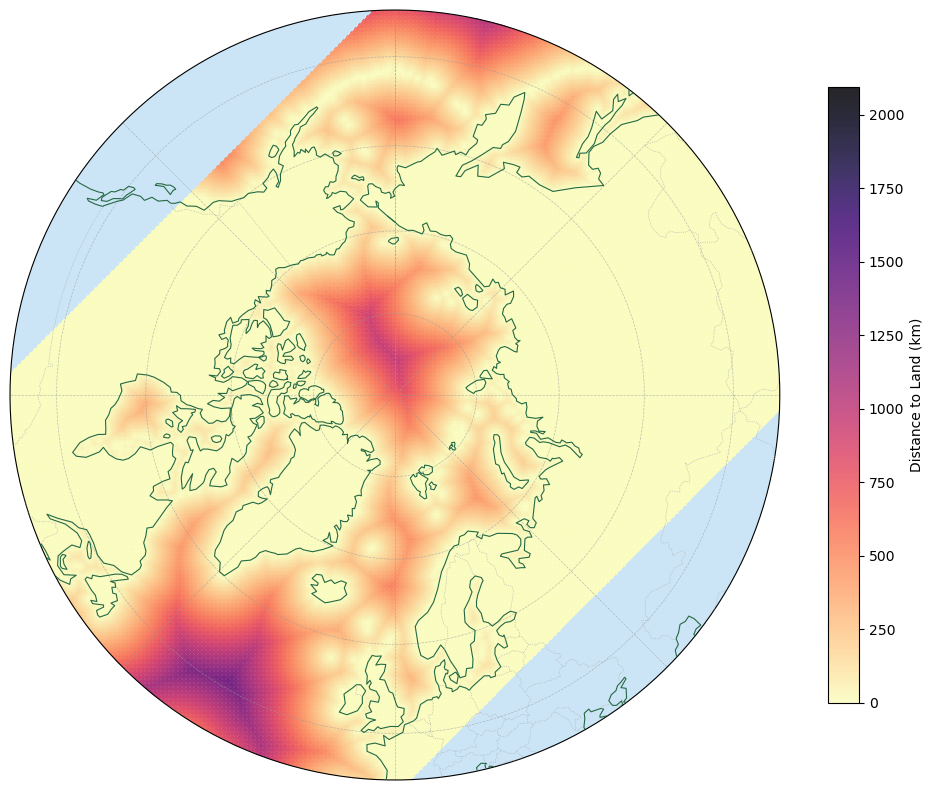

In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# NSIDC NH polar stereographic grid parameters
# EPSG:3411

NROWS      = 448
NCOLS      = 304
PIXEL_SIZE = 25000   # metres
X_ORIGIN   = -3830000
Y_ORIGIN   =  5830000

file_path = '../../local_data/nsidc_distance_to_land.nc'
ds = xr.open_dataarray(file_path)
ds_km = ds / 1000.0  # Convert to km for the plot

# reconstruct the X and Y coordinates in EPSG:3411 meters to map the 2D array accurately

x_coords = X_ORIGIN + (np.arange(NCOLS) + 0.5) * PIXEL_SIZE
y_coords = Y_ORIGIN + (np.arange(NROWS) + 0.5) * (-PIXEL_SIZE)

# define the native projection of the NSIDC data (EPSG:3411)

nsidc_crs = ccrs.Stereographic(
    central_latitude=90, 
    central_longitude=-45, 
    true_scale_latitude=70
)

# define the projection for the plot map

plot_crs = ccrs.NorthPolarStereo(central_longitude=0)
data_crs = ccrs.PlateCarree()

# figure setip

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': plot_crs})
fig.patch.set_facecolor('white')

# add circular boundary

def make_circular_boundary(ax, lat_min=45):
    theta = np.linspace(0, 2 * np.pi, 200)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)
    ax.set_extent([-180, 180, lat_min, 90], crs=data_crs)

make_circular_boundary(ax, lat_min=45)

# add base colors and features

ax.set_facecolor('#cce5f6')

# plot heatmap data
# use pcolormesh and transform from the native NSIDC CRS to the map CRS

mesh = ax.pcolormesh(
    x_coords, y_coords, ds_km.values,
    transform=nsidc_crs,
    cmap='magma_r',
    alpha=0.85,
    zorder=2
)

# overlay cartopy coastlines and borders

ax.add_feature(cfeature.COASTLINE, edgecolor="#256844", linewidth=0.8, zorder=3)
ax.add_feature(cfeature.BORDERS, edgecolor='#aaaaaa', linewidth=0.5, linestyle=':', zorder=3)

# add gridlines

gl = ax.gridlines(
    crs=data_crs,
    draw_labels=False,
    linewidth=0.5,
    color='#999999',
    alpha=0.6,
    linestyle='--',
    zorder=4
)
gl.ylocator = plt.FixedLocator([50, 60, 70, 80])
gl.xlocator = plt.FixedLocator(np.arange(-180, 181, 45))

# formatting

cbar = plt.colorbar(mesh, ax=ax, shrink=0.8, pad=0.05, label='Distance to Land (km)')

plt.tight_layout()
plt.savefig('../../figures/Misc/nsidc_distance_to_land_map.png', dpi=300, bbox_inches='tight')
plt.show()